#PROJECT: Satellite Brightness Prediction using Machine Learning

#Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [3]:
df = pd.read_csv('satellite_observations_all.csv')
df.head()

,satellite_name,norad_cat_id,observation_time_utc,observation_time_uncertainty_sec,apparent_magnitude,apparent_magnitude_uncertainty,observer_latitude_deg,observer_longitude_deg,observer_altitude_m,limiting_magnitude,...,dra_cosdec_deg_s_satchecker,phase_angle_deg_satchecker,alt_deg_satchecker,az_deg_satchecker,sat_altitude_km_satchecker,solar_elevation_deg_satchecker,solar_azimuth_deg_satchecker,illuminated,international_designator,potentially_discrepant
0,ACS 3,59588,2024-10-04T19:32:05.573Z,0.001,5.994933,0.276286,52.15399,4.49085,8.0,10.0,...,-0.037357,48.827784,44.591865,165.236404,1034.523757,-22.027591,291.989957,True,2024-077B,False
1,ACS 3,59588,2024-10-03T19:00:27.319Z,0.001,6.683010,0.096618,52.15399,4.49085,8.0,10.0,...,0.051040,29.198546,42.344587,122.488976,1035.176737,-17.067364,285.365435,True,2024-077B,False
2,ACS 3,59588,2024-10-03T19:00:27.359Z,0.001,6.736305,0.128848,52.15399,4.49085,8.0,10.0,...,0.051057,29.200426,42.352010,122.479511,1035.176313,-17.067463,285.365575,True,2024-077B,False
3,ACS 3,59588,2024-10-03T19:00:27.399Z,0.001,6.735408,0.128820,52.15399,4.49085,8.0,10.0,...,0.051075,29.202310,42.359432,122.470042,1035.175889,-17.067562,285.365715,True,2024-077B,False
4,STARLINK-31370,59520,2024-04-29T10:28:45.000Z,0.300,2.400000,0.200000,36.12800,-95.98800,201.0,8.0,...,0.946890,80.707383,52.748984,149.723108,330.363999,-12.643098,60.960089,True,2024-073K,False


#Understand Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31679 entries, 0 to 31678
Data columns (total 41 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   satellite_name                                  31679 non-null  object 
 1   norad_cat_id                                    31679 non-null  int64  
 2   observation_time_utc                            31679 non-null  object 
 3   observation_time_uncertainty_sec                31679 non-null  float64
 4   apparent_magnitude                              31674 non-null  float64
 5   apparent_magnitude_uncertainty                  31674 non-null  float64
 6   observer_latitude_deg                           31679 non-null  float64
 7   observer_longitude_deg                          31679 non-null  float64
 8   observer_altitude_m                             31679 non-null  float64
 9   limiting_magnitude                     

In [5]:
df.describe()

,norad_cat_id,observation_time_uncertainty_sec,apparent_magnitude,apparent_magnitude_uncertainty,observer_latitude_deg,observer_longitude_deg,observer_altitude_m,limiting_magnitude,satellite_right_ascension_deg,satellite_declination_deg,...,range_to_sat_km_satchecker,range_rate_sat_km_s_satchecker,ddec_deg_s_satchecker,dra_cosdec_deg_s_satchecker,phase_angle_deg_satchecker,alt_deg_satchecker,az_deg_satchecker,sat_altitude_km_satchecker,solar_elevation_deg_satchecker,solar_azimuth_deg_satchecker
count,31679.000000,31679.000000,31674.000000,31674.000000,31679.000000,31679.000000,31679.000000,31679.000000,25694.000000,25694.000000,...,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000,31651.000000
mean,59860.815209,0.202940,5.491368,0.233828,50.562993,6.936936,257.323355,8.887764,297.469328,25.077486,...,1208.591262,-1.763937,0.205443,-0.119651,65.971295,51.361835,178.716366,936.531116,-19.236866,277.202709
std,1599.817143,0.602248,1.783320,0.179906,3.593639,22.370277,644.407824,3.326173,41.995912,21.452306,...,326.999705,2.931543,0.195892,4.757158,24.698547,14.063274,72.050879,204.211003,4.439954,63.984455
min,17191.000000,0.001000,-0.028415,0.010000,28.298974,-110.767594,0.000000,0.000000,0.900000,-28.900000,...,339.117152,-6.857863,-0.977306,-179.442772,5.942229,-4.465443,0.122416,302.048285,-40.914100,0.046025
25%,59588.000000,0.001000,3.888442,0.129796,52.153990,4.490850,8.000000,10.000000,282.341786,7.370358,...,1087.109812,-4.227802,0.167494,-0.114469,48.123352,40.974250,133.392182,1031.722614,-22.020670,289.463808
50%,59588.000000,0.001000,5.844136,0.200000,52.153990,4.490850,8.000000,10.000000,308.117725,21.693634,...,1219.434431,-2.528893,0.243035,-0.026026,61.573298,51.140223,165.951659,1035.189860,-17.614577,296.156729
75%,59588.000000,0.001000,6.807388,0.272676,52.153990,4.490850,8.000000,10.000000,323.270684,40.647325,...,1408.514446,0.436912,0.316311,0.046303,80.677782,61.634662,218.626696,1039.123826,-16.419292,299.771735
max,67232.000000,5.000000,12.540000,5.042254,52.153990,117.574200,2361.870000,19.520000,359.500000,84.500000,...,3902.139845,6.883396,0.997665,1.178428,157.568306,88.634909,359.904043,1085.206348,-7.287239,357.844181


#Data Cleaning

In [6]:
features = [
    'range_to_satellite_km',
    'range_rate_of_satellite_km_per_sec',
    'observer_latitude_deg',
    'observer_longitude_deg',
    'satellite_declination_deg',
    'satellite_right_ascension_deg',
    'limiting_magnitude'
]

df_ml = df[features + ['apparent_magnitude']].dropna()

#Exploratory Data Analysis(EDA)

---



###**Brightness** Distribution

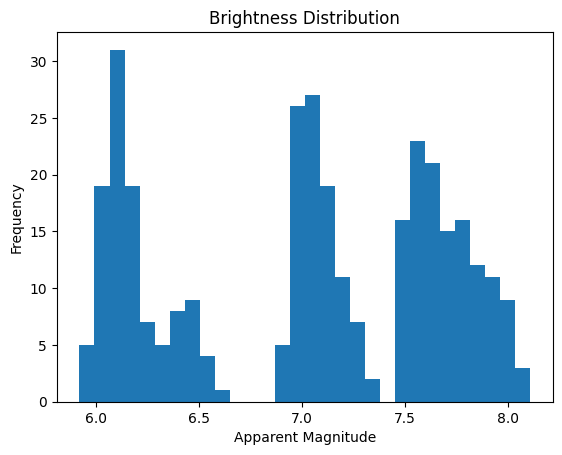

In [7]:
plt.hist(df_ml['apparent_magnitude'], bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Apparent Magnitude")
plt.ylabel("Frequency")
plt.show()

###Distance vs Brightness

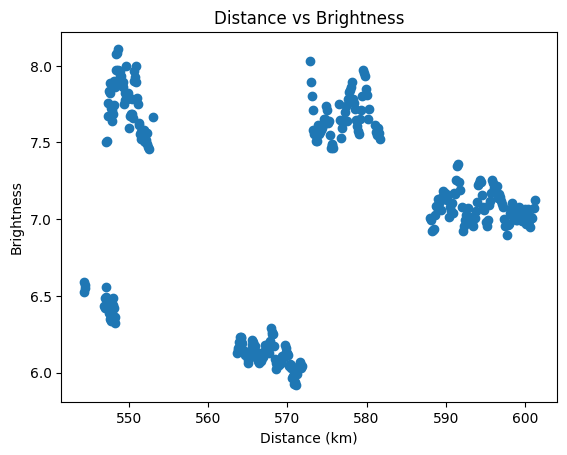

In [8]:
plt.scatter(df_ml['range_to_satellite_km'], df_ml['apparent_magnitude'])
plt.xlabel("Distance (km)")
plt.ylabel("Brightness")
plt.title("Distance vs Brightness")
plt.show()

#Feature  & Target Selection

In [9]:
X = df_ml[features]
y = df_ml['apparent_magnitude']

#Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model Building(Random Forest)

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

#Prediction

In [12]:
y_pred = rf_model.predict(X_test)

#Model Evaluation

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.004460721326857632
R2 Score: 0.9905115027928417


#Actual vs Predicted Visualization

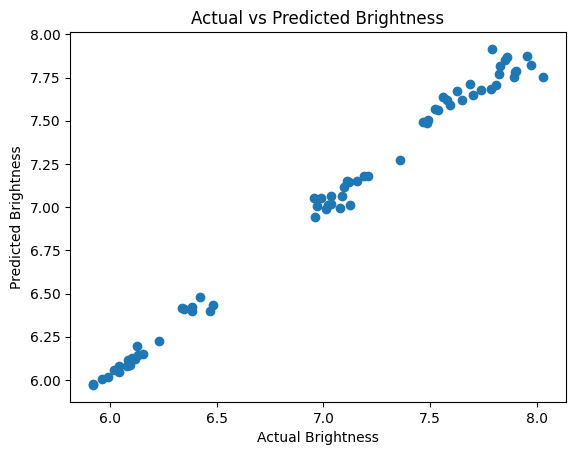

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Brightness")
plt.ylabel("Predicted Brightness")
plt.title("Actual vs Predicted Brightness")
plt.show()

#Feature Importance Analysis

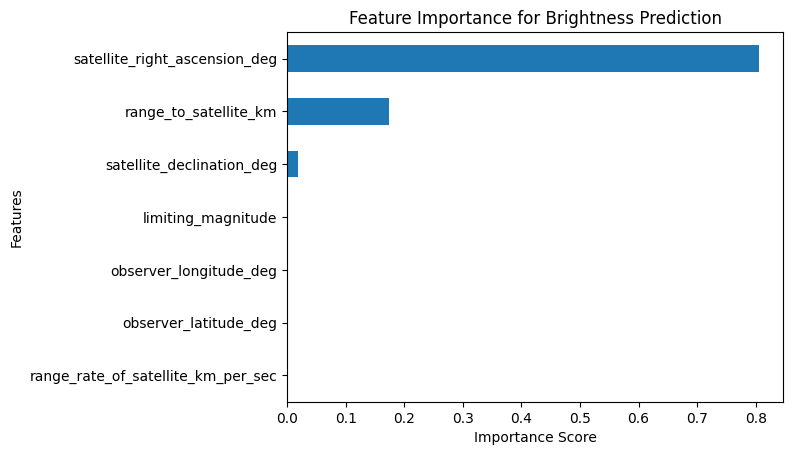

In [15]:
importance = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.sort_values(ascending=True).plot(kind='barh')
plt.title("Feature Importance for Brightness Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#Conclusion

In [16]:
print("""
Conclusion:
The project successfully predicts satellite brightness using machine learning.
The Random Forest model achieved a high R2 score, indicating strong predictive performance.
Feature importance analysis shows that satellite position and distance are key factors influencing brightness.
""")


Conclusion:
The project successfully predicts satellite brightness using machine learning.
The Random Forest model achieved a high R2 score, indicating strong predictive performance.
Feature importance analysis shows that satellite position and distance are key factors influencing brightness.

